# 01 — Exploratory data analysis

Eight angles on the Kaggle *Store Sales* data (PLAN.md P0.3), each with one chart saved to
`docs/figures/` and summarised in `docs/eda-findings.md`.

**Redistribution note:** this repo is public, so this notebook only ever prints *aggregates* —
never raw rows of the Kaggle files (see `data/README.md`).

Run: `uv run jupyter nbconvert --to notebook --execute notebooks/01_eda.ipynb --output 01_eda.ipynb`

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from forecasting_platform.config import PROJECT_ROOT, settings

# numpy 2.4 deprecation raised inside pandas Timestamp/Timedelta arithmetic — not actionable.
warnings.filterwarnings("ignore", category=DeprecationWarning)

RAW = settings.DATA_RAW_DIR
FIG_DIR = PROJECT_ROOT / "docs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Validated categorical palette (light mode), used in fixed slot order; gray for context marks.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
CONTEXT, INK, INK_2, GRID, SURFACE = "#b5b4ae", "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"

plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "axes.edgecolor": GRID,
        "axes.labelcolor": INK_2,
        "axes.titlecolor": INK,
        "axes.titlesize": 11,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "axes.axisbelow": True,
        "grid.color": GRID,
        "grid.linewidth": 0.6,
        "xtick.color": INK_2,
        "ytick.color": INK_2,
        "font.size": 9,
        "legend.frameon": False,
        "figure.dpi": 100,
    }
)


def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()


train = pd.read_csv(RAW / "train.csv", parse_dates=["date"])
stores = pd.read_csv(RAW / "stores.csv")
oil = pd.read_csv(RAW / "oil.csv", parse_dates=["date"])
holidays = pd.read_csv(RAW / "holidays_events.csv", parse_dates=["date"])

daily = train.groupby("date")["sales"].sum()
store_day = train.groupby(["store_nbr", "date"])["sales"].sum()
print(
    f"train: {len(train):,} rows, {train['store_nbr'].nunique()} stores, "
    f"{train['family'].nunique()} families, {daily.index.min().date()}..{daily.index.max().date()}"
)

train: 3,000,888 rows, 54 stores, 33 families, 2013-01-01..2017-08-15


## 1. Aggregate trend and seasonality

Dates absent from train.csv: ['2013-12-25', '2014-12-25', '2015-12-25', '2016-12-25']
Mean daily total: 2013 = 385,767; last 12 months = 841,507 (2.18x)
Day-of-week index (Mon..Sun): [0.97, 0.89, 0.93, 0.79, 0.91, 1.21, 1.29]
Month index (Jan..Dec): [0.95, 0.89, 0.98, 0.94, 0.95, 0.98, 1.04, 0.94, 1.01, 1.01, 1.04, 1.26]


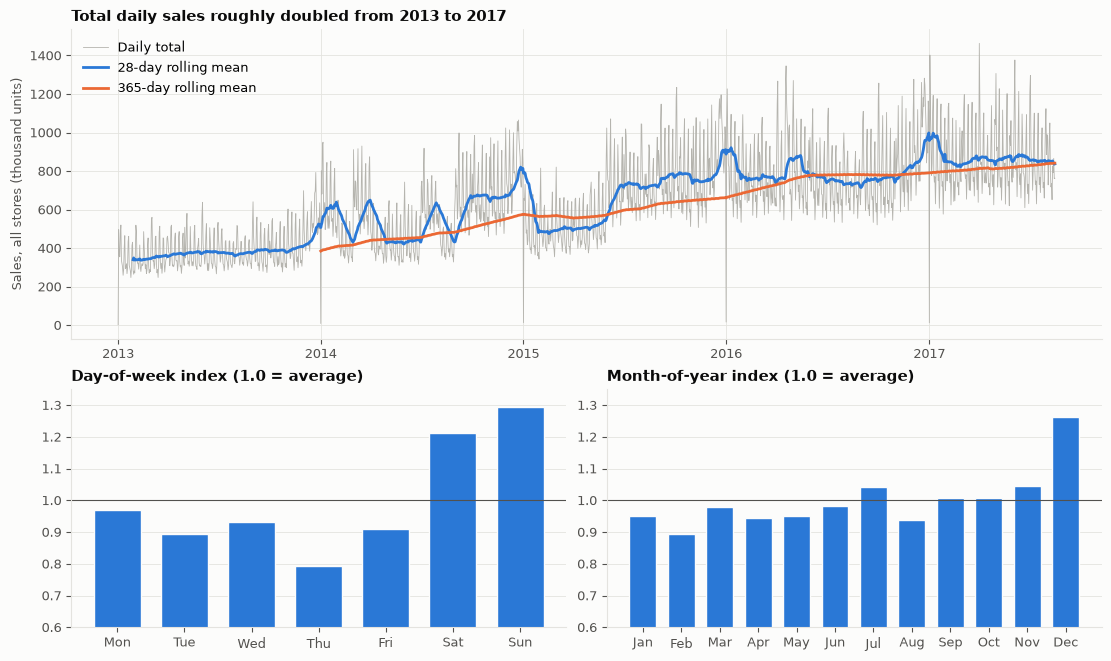

In [2]:
calendar = pd.date_range(daily.index.min(), daily.index.max(), freq="D")
print(
    "Dates absent from train.csv:", [d.date().isoformat() for d in calendar.difference(daily.index)]
)

first_year, last_year = daily[:"2013-12-31"].mean(), daily["2016-08-16":].mean()
print(
    f"Mean daily total: 2013 = {first_year:,.0f}; last 12 months = {last_year:,.0f} "
    f"({last_year / first_year:.2f}x)"
)

dow_idx = daily.groupby(daily.index.dayofweek).mean()
dow_idx /= dow_idx.mean()
month_idx = daily.groupby(daily.index.month).mean()
month_idx /= month_idx.mean()
print("Day-of-week index (Mon..Sun):", dow_idx.round(2).tolist())
print("Month index (Jan..Dec):", month_idx.round(2).tolist())

fig = plt.figure(figsize=(11, 6.5), layout="constrained")
gs = fig.add_gridspec(2, 2, height_ratios=[1.3, 1])
ax = fig.add_subplot(gs[0, :])
ax.plot(daily.index, daily / 1e3, color=CONTEXT, lw=0.6, label="Daily total")
ax.plot(daily.rolling(28).mean() / 1e3, color=BLUE, lw=2, label="28-day rolling mean")
ax.plot(daily.rolling(365).mean() / 1e3, color=ORANGE, lw=2, label="365-day rolling mean")
ax.set_ylabel("Sales, all stores (thousand units)")
ax.set_title("Total daily sales roughly doubled from 2013 to 2017")
ax.legend(loc="upper left")
for pos, idx, labels, title in [
    (gs[1, 0], dow_idx, ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"], "Day-of-week index"),
    (
        gs[1, 1],
        month_idx,
        ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
        "Month-of-year index",
    ),
]:
    a = fig.add_subplot(pos)
    a.bar(labels, idx.to_numpy(), color=BLUE, width=0.7, edgecolor=SURFACE, linewidth=1)
    a.axhline(1, color=INK_2, lw=0.8)
    a.set_ylim(0.6, 1.35)
    a.grid(axis="x", visible=False)
    a.set_title(f"{title} (1.0 = average)")
save(fig, "01_trend_seasonality")

## 2. Zero-inflation / intermittent demand

A zero in `sales` means three different things, and they need different handling downstream:
**store closed** (every family at that store sold nothing that day), **before first sale** (the
store–family series hasn't started recording yet — or never does), and **zero while active**
(genuine intermittent demand).

Rows with sales == 0: 31.3%
kind
sold                 68.7
Zero while active    12.2
Before first sale    11.1
Store closed          8.1
Store-days with zero sales in every family (closed): 7,330 of 90,936 (8.1%); most common date: 1 January (264 store-days)
Families with no sales recorded anywhere before:
family
PRODUCE                       2013-03-16
CELEBRATION                   2014-01-01
HOME AND KITCHEN I            2014-01-01
HOME AND KITCHEN II           2014-01-01
HOME CARE                     2014-01-01
MAGAZINES                     2014-01-01
PET SUPPLIES                  2014-01-01
PLAYERS AND ELECTRONICS       2014-01-01
LADIESWEAR                    2014-01-02
SCHOOL AND OFFICE SUPPLIES    2014-01-02
BABY CARE                     2014-03-01
BOOKS                         2016-10-08



Zero share by family (%), sorted:
kind                        Store closed  Before first sale  Zero while active  total
family                                                                               
BREAD/BAKERY                         8.1                0.0                0.0    8.1
BEVERAGES                            8.1                0.0                0.0    8.1
MEATS                                8.1                0.0                0.0    8.1
CLEANING                             8.1                0.0                0.0    8.1
DAIRY                                8.1                0.0                0.0    8.1
DELI                                 8.1                0.0                0.0    8.1
EGGS                                 8.1                0.0                0.0    8.1
GROCERY I                            8.1                0.0                0.0    8.1
PERSONAL CARE                        8.1                0.0                0.0    8.1
POULTRY            

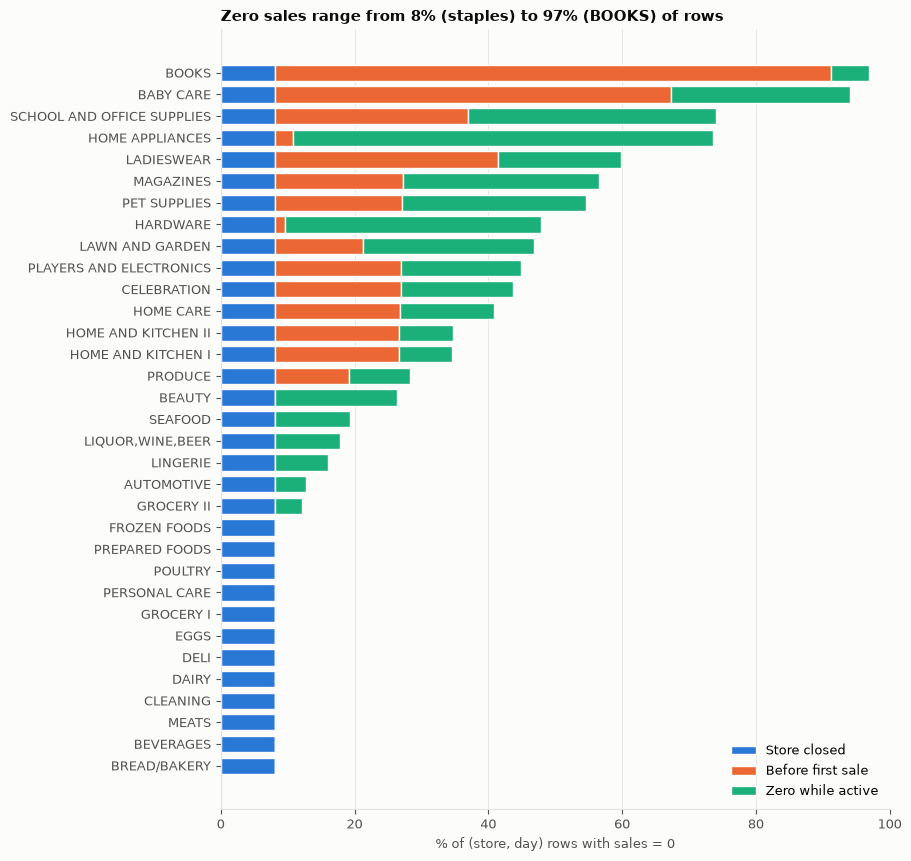

In [3]:
closed_idx = store_day[store_day == 0].index
is_closed = pd.MultiIndex.from_frame(train[["store_nbr", "date"]]).isin(closed_idx)
first_sale = (
    train[train["sales"] > 0].groupby(["store_nbr", "family"])["date"].min().rename("first_sale")
)
t = train[["store_nbr", "family", "date", "sales"]].join(first_sale, on=["store_nbr", "family"])
before_first = t["first_sale"].isna() | (t["date"] < t["first_sale"])
zero = t["sales"] == 0
t["kind"] = np.select(
    [~zero, is_closed, before_first],
    ["sold", "Store closed", "Before first sale"],
    "Zero while active",
)

print(f"Rows with sales == 0: {zero.mean():.1%}")
print(t["kind"].value_counts(normalize=True).mul(100).round(1).to_string())
print(
    f"Store-days with zero sales in every family (closed): {len(closed_idx):,} "
    f"of {len(store_day):,} "
    f"({len(closed_idx) / len(store_day):.1%}); most common date: 1 January "
    f"({(closed_idx.get_level_values('date').strftime('%m-%d') == '01-01').sum()} store-days)"
)

national_first = train[train["sales"] > 0].groupby("family")["date"].min()
print("Families with no sales recorded anywhere before:")
print(national_first[national_first > "2013-01-02"].dt.date.sort_values().to_string())

kinds = ["Store closed", "Before first sale", "Zero while active"]
shares = pd.crosstab(t["family"], t["kind"], normalize="index")[kinds] * 100
shares = shares.loc[shares.sum(axis=1).sort_values().index]
print("\nZero share by family (%), sorted:")
print(shares.assign(total=shares.sum(axis=1)).round(1).to_string())

fig, ax = plt.subplots(figsize=(9, 8.5), layout="constrained")
left = np.zeros(len(shares))
for kind, color in zip(kinds, [BLUE, ORANGE, AQUA], strict=True):
    ax.barh(
        shares.index,
        shares[kind],
        left=left,
        color=color,
        label=kind,
        edgecolor=SURFACE,
        linewidth=1,
        height=0.75,
    )
    left += shares[kind].to_numpy()
ax.set_xlabel("% of (store, day) rows with sales = 0")
ax.set_xlim(0, 100)
ax.grid(axis="y", visible=False)
ax.set_title("Zero sales range from 8% (staples) to 97% (BOOKS) of rows")
ax.legend(loc="lower right")
save(fig, "02_zero_inflation")

## 3. Holiday effects

`holidays_events.csv` subtlety: a `Holiday` row with `transferred == True` is a **normal working
day** — the holiday is observed on the paired `Transfer` row's date instead. Effects are measured
as the ratio of national daily sales to the mean of non-holiday days with the same year and
day-of-week (controls for trend and weekly seasonality).

                                                              n_days  median_ratio  mean_ratio
group                                                                                         
Holiday, observed\n(type Holiday/Transfer,\nnot transferred)      47         1.068       1.036
Holiday row with\ntransferred=True\n(normal working day)           7         0.918       0.820
Additional / Bridge\n(extended holidays)                          31         1.539       1.543
Work Day\n(make-up working day)                                    5         0.993       0.976
1 January alone (most stores closed): median ratio 0.02
type == Holiday & National & not transferred: mean national sales 614,994 vs non-holiday days 628,494


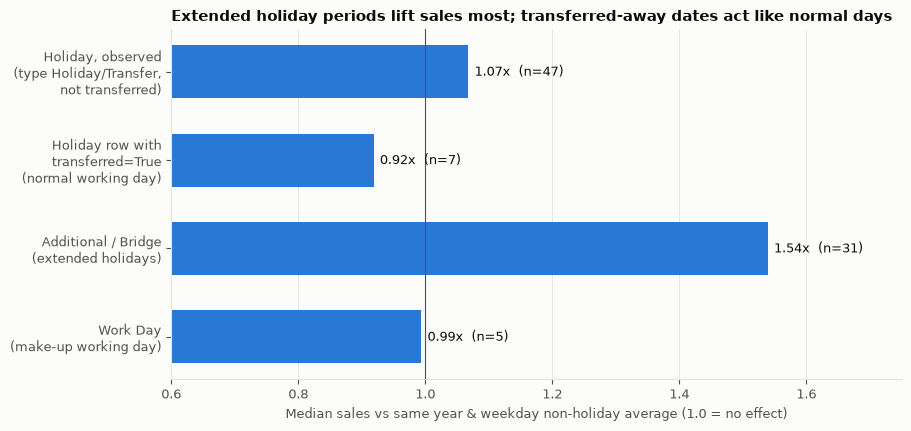

In [4]:
nat = holidays[holidays["locale"] == "National"]
d = daily.to_frame("sales")
d["year"], d["dow"] = d.index.year, d.index.dayofweek
baseline = d[~d.index.isin(nat["date"])].groupby(["year", "dow"])["sales"].mean()
d["ratio"] = (
    d["sales"] / baseline.reindex(pd.MultiIndex.from_arrays([d["year"], d["dow"]])).to_numpy()
)

groups = {
    "Holiday, observed\n(type Holiday/Transfer,\nnot transferred)": nat[
        nat["type"].isin(["Holiday", "Transfer"]) & ~nat["transferred"]
    ]["date"],
    "Holiday row with\ntransferred=True\n(normal working day)": nat[nat["transferred"]]["date"],
    "Additional / Bridge\n(extended holidays)": nat[nat["type"].isin(["Additional", "Bridge"])][
        "date"
    ],
    "Work Day\n(make-up working day)": nat[nat["type"] == "Work Day"]["date"],
}
rows = []
for name, dates in groups.items():
    r = d.loc[d.index.isin(dates), "ratio"]
    rows.append(
        {"group": name, "n_days": len(r), "median_ratio": r.median(), "mean_ratio": r.mean()}
    )
summary = pd.DataFrame(rows).set_index("group")
print(summary.round(3).to_string())
jan1 = d.loc[(d.index.month == 1) & (d.index.day == 1), "ratio"]
print(f"1 January alone (most stores closed): median ratio {jan1.median():.2f}")
obs_type_holiday = nat[(nat["type"] == "Holiday") & ~nat["transferred"]]["date"]
print(
    f"type == Holiday & National & not transferred: mean national sales "
    f"{d.loc[d.index.isin(obs_type_holiday), 'sales'].mean():,.0f} vs non-holiday days "
    f"{d.loc[~d.index.isin(nat['date']), 'sales'].mean():,.0f}"
)

fig, ax = plt.subplots(figsize=(9, 4.2), layout="constrained")
y = np.arange(len(summary))[::-1]
ax.barh(y, summary["median_ratio"], color=BLUE, height=0.6)
ax.axvline(1, color=INK_2, lw=0.8)
for yi, (_, row) in zip(y, summary.iterrows(), strict=True):
    ax.text(
        row["median_ratio"] + 0.01,
        yi,
        f"{row['median_ratio']:.2f}x  (n={row['n_days']:.0f})",
        va="center",
        color=INK,
    )
ax.set_yticks(y, summary.index)
ax.set_xlim(0.6, 1.75)
ax.grid(axis="y", visible=False)
ax.set_xlabel("Median sales vs same year & weekday non-holiday average (1.0 = no effect)")
ax.set_title(
    "Extended holiday periods lift sales most; transferred-away dates act like normal days"
)
save(fig, "03_holiday_effects")

## 4. Promotion effect by family

`onpromotion` is zero everywhere before 2014-04-01 (promotions weren't recorded before then), so
this uses 2014-04-01 onward. The statistic is the **median, across stores, of the within-series
Spearman correlation** between `onpromotion` and `sales` — computing it within each store–family
series avoids the store-size confound a pooled correlation would have. Correlational, not causal:
promotions are chosen by the retailer and co-trend with sales.

First date with onpromotion > 0: 2014-04-01


Families with no promo variation (excluded): ['BOOKS']
Weakest: {'HARDWARE': 0.04, 'LADIESWEAR': 0.05, 'HOME APPLIANCES': 0.05, 'MAGAZINES': 0.06, 'PLAYERS AND ELECTRONICS': 0.07}
Strongest: {'HOME CARE': 0.41, 'HOME AND KITCHEN II': 0.42, 'SCHOOL AND OFFICE SUPPLIES': 0.49, 'BEVERAGES': 0.54, 'PRODUCE': 0.55}


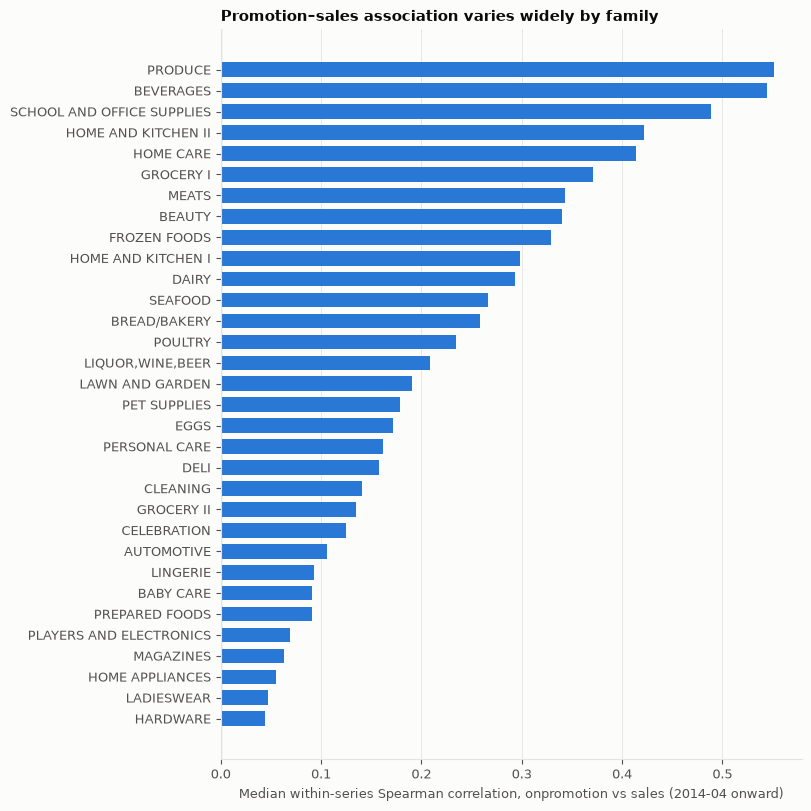

In [5]:
print("First date with onpromotion > 0:", train.loc[train["onpromotion"] > 0, "date"].min().date())
promo = train[train["date"] >= "2014-04-01"]


def spearman(g):
    if g["onpromotion"].nunique() < 2 or g["sales"].nunique() < 2:
        return np.nan
    return g["sales"].corr(g["onpromotion"], method="spearman")


series_corr = promo.groupby(["family", "store_nbr"])[["sales", "onpromotion"]].apply(spearman)
fam_corr = series_corr.groupby("family").median().dropna().sort_values()
print(
    "Families with no promo variation (excluded):",
    sorted(set(train["family"]) - set(fam_corr.index)),
)
print("Weakest:", fam_corr.head(5).round(2).to_dict())
print("Strongest:", fam_corr.tail(5).round(2).to_dict())

fig, ax = plt.subplots(figsize=(8, 8), layout="constrained")
ax.barh(fam_corr.index, fam_corr, color=BLUE, height=0.7)
ax.axvline(0, color=INK_2, lw=0.8)
ax.grid(axis="y", visible=False)
ax.set_xlabel("Median within-series Spearman correlation, onpromotion vs sales (2014-04 onward)")
ax.set_title("Promotion–sales association varies widely by family")
save(fig, "04_promotion_effect")

## 5. Store heterogeneity (type and cluster)

Average daily sales per store, over days the store was open (store-closed days excluded).

      count   median      min      max
type                                  
A         9  24953.0  17066.0  36979.0
B         8  12201.0   8451.0  16870.0
C        15   6584.0   3545.0  10956.0
D        18  11345.0   4619.0  30067.0
E         4  10408.0   9786.0  11102.0
Largest vs smallest store: 36,979 vs 3,545 (10.4x)
Cluster medians range 6,509 .. 36,979


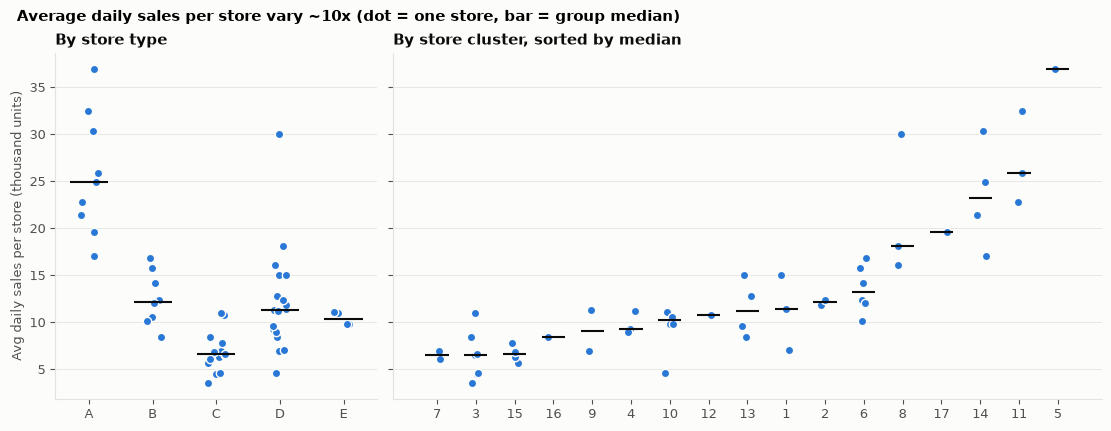

In [6]:
store_avg = (
    store_day[store_day > 0]
    .groupby("store_nbr")
    .mean()
    .rename("avg_daily_sales")
    .to_frame()
    .join(stores.set_index("store_nbr"))
)
by_type = store_avg.groupby("type")["avg_daily_sales"].agg(["count", "median", "min", "max"])
print(by_type.round(0).to_string())
print(
    f"Largest vs smallest store: {store_avg['avg_daily_sales'].max():,.0f} vs "
    f"{store_avg['avg_daily_sales'].min():,.0f} "
    f"({store_avg['avg_daily_sales'].max() / store_avg['avg_daily_sales'].min():.1f}x)"
)
by_cluster = store_avg.groupby("cluster")["avg_daily_sales"].median().sort_values()
print(f"Cluster medians range {by_cluster.min():,.0f} .. {by_cluster.max():,.0f}")

rng = np.random.default_rng(settings.RANDOM_SEED)
fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.2),
    layout="constrained",
    sharey=True,
    gridspec_kw={"width_ratios": [1, 2.2]},
)
for ax, key, order in [
    (axes[0], "type", sorted(stores["type"].unique())),
    (axes[1], "cluster", list(by_cluster.index)),
]:
    for i, level in enumerate(order):
        vals = store_avg.loc[store_avg[key] == level, "avg_daily_sales"] / 1e3
        ax.scatter(
            i + rng.uniform(-0.15, 0.15, len(vals)),
            vals,
            s=36,
            color=BLUE,
            edgecolor=SURFACE,
            linewidth=1,
            zorder=3,
        )
        ax.hlines(vals.median(), i - 0.3, i + 0.3, color=INK, lw=1.5, zorder=4)
    ax.set_xticks(range(len(order)), [str(o) for o in order])
    ax.grid(axis="x", visible=False)
axes[0].set_ylabel("Avg daily sales per store (thousand units)")
axes[0].set_title("By store type")
axes[1].set_title("By store cluster, sorted by median")
fig.suptitle(
    "Average daily sales per store vary ~10x (dot = one store, bar = group median)",
    x=0.01,
    ha="left",
    fontweight="bold",
    fontsize=11,
)
save(fig, "05_store_heterogeneity")

## 6. Oil price vs national sales

Correlating raw *levels* of two trending series is a classic spurious-correlation trap, so both
levels and month-over-month *changes* are shown.

Oil price: 2013 mean $98, 2016 mean $43
Correlation of levels: daily r = -0.63, monthly r = -0.79
Correlation of month-over-month % changes: r = 0.06 (n = 55)


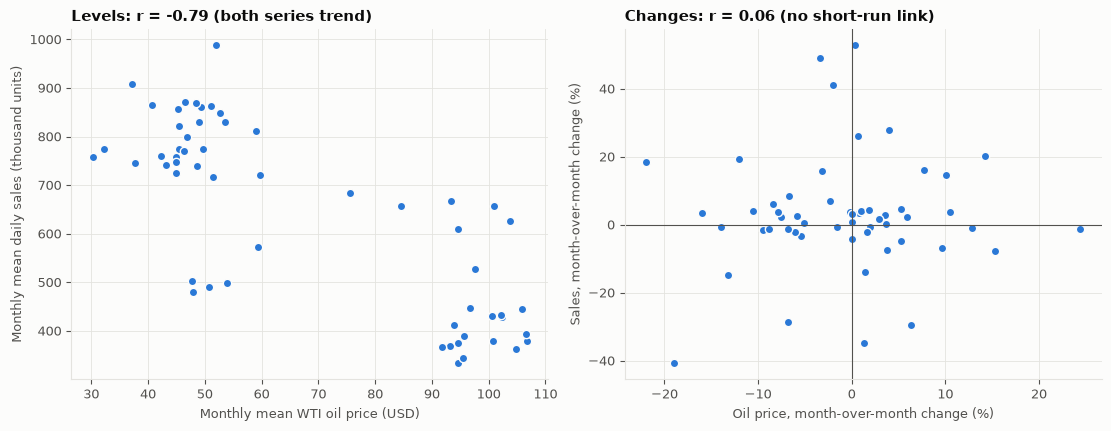

In [7]:
oil_s = oil.set_index("date")["dcoilwtico"]
oil_daily = oil_s.reindex(calendar).ffill().bfill()
monthly = pd.DataFrame(
    {"sales": daily.resample("MS").mean(), "oil": oil_daily.resample("MS").mean()}
)
changes = monthly.pct_change().dropna()
r_level_daily = daily.corr(oil_daily.reindex(daily.index))
r_level = monthly["sales"].corr(monthly["oil"])
r_change = changes["sales"].corr(changes["oil"])
print(f"Oil price: 2013 mean ${oil_s[:'2013'].mean():.0f}, 2016 mean ${oil_s['2016'].mean():.0f}")
print(f"Correlation of levels: daily r = {r_level_daily:.2f}, monthly r = {r_level:.2f}")
print(f"Correlation of month-over-month % changes: r = {r_change:.2f} (n = {len(changes)})")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), layout="constrained")
axes[0].scatter(monthly["oil"], monthly["sales"] / 1e3, s=36, color=BLUE, edgecolor=SURFACE)
axes[0].set_xlabel("Monthly mean WTI oil price (USD)")
axes[0].set_ylabel("Monthly mean daily sales (thousand units)")
axes[0].set_title(f"Levels: r = {r_level:.2f} (both series trend)")
axes[1].scatter(changes["oil"] * 100, changes["sales"] * 100, s=36, color=BLUE, edgecolor=SURFACE)
axes[1].axhline(0, color=INK_2, lw=0.8)
axes[1].axvline(0, color=INK_2, lw=0.8)
axes[1].set_xlabel("Oil price, month-over-month change (%)")
axes[1].set_ylabel("Sales, month-over-month change (%)")
axes[1].set_title(f"Changes: r = {r_change:.2f} (no short-run link)")
save(fig, "06_oil_vs_sales")

## 7. Regime shift — the 2016-04-16 Ecuador earthquake

The magnitude-7.8 earthquake struck Manabí province (with heavy damage in neighbouring
Esmeraldas). "Affected" = stores in those two provinces that were open before the quake; "rest"
= every other store open by then. Sales are indexed to each group's 28 pre-quake days (7-day
trailing mean). The same calendar window in 2015 is a placebo check: it shows what an ordinary
mid-April looks like, including the 15 April public-sector payday.

Affected stores: [43, 53, 54] (Esmeraldas, Manta, El Carmen); rest: 50 stores
Sales vs 28-day pre-window (1.00 = unchanged):
year           2015           2016      
group      affected  rest affected  rest
window                                  
days 0-6       0.98  1.00     1.40  1.42
days 7-13      0.94  0.92     1.24  1.00
days 14-27     1.16  1.10     1.49  1.08
days 28-55     1.28  1.27     1.46  1.01


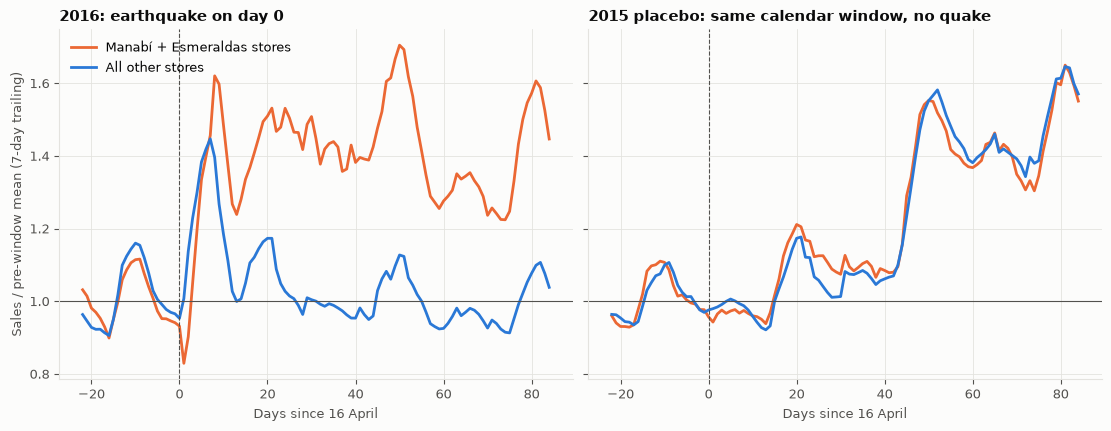

In [8]:
QUAKE = pd.Timestamp("2016-04-16")
store_open = store_day[store_day > 0].reset_index().groupby("store_nbr")["date"].min()
open_early = set(store_open[store_open < QUAKE - pd.Timedelta(days=28)].index)
region = stores.set_index("store_nbr")["state"]
affected = sorted(s for s in open_early if region[s] in ("Manabi", "Esmeraldas"))
rest = sorted(open_early - set(affected))
print(
    f"Affected stores: {affected} "
    f"({', '.join(stores.set_index('store_nbr').loc[affected, 'city'])}); "
    f"rest: {len(rest)} stores"
)
wide = store_day.unstack("store_nbr")

rows, curves = [], {}
for anchor in [QUAKE, pd.Timestamp("2015-04-16")]:
    pre = wide.loc[anchor - pd.Timedelta(days=28) : anchor - pd.Timedelta(days=1)]
    for grp, cols in [("affected", affected), ("rest", rest)]:
        base = pre[cols].sum(axis=1).mean()
        series = (
            wide.loc[anchor - pd.Timedelta(days=28) : anchor + pd.Timedelta(days=84), cols].sum(
                axis=1
            )
            / base
        )
        curves[(anchor.year, grp)] = series.rolling(7).mean().set_axis((series.index - anchor).days)
        for a, b in [(0, 6), (7, 13), (14, 27), (28, 55)]:
            rows.append(
                {
                    "year": anchor.year,
                    "group": grp,
                    "window": f"days {a}-{b}",
                    "ratio": series.loc[
                        anchor + pd.Timedelta(days=a) : anchor + pd.Timedelta(days=b)
                    ].mean(),
                }
            )
table = pd.DataFrame(rows).pivot_table(index="window", columns=["year", "group"], values="ratio")
table = table.reindex(["days 0-6", "days 7-13", "days 14-27", "days 28-55"])
print("Sales vs 28-day pre-window (1.00 = unchanged):")
print(table.round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), layout="constrained", sharey=True)
for ax, year in zip(axes, [2016, 2015], strict=True):
    ax.plot(curves[(year, "affected")], color=ORANGE, lw=2, label="Manabí + Esmeraldas stores")
    ax.plot(curves[(year, "rest")], color=BLUE, lw=2, label="All other stores")
    ax.axvline(0, color=INK_2, lw=0.8, ls="--")
    ax.axhline(1, color=INK_2, lw=0.8)
    ax.set_xlabel("Days since 16 April")
axes[0].set_title("2016: earthquake on day 0")
axes[1].set_title("2015 placebo: same calendar window, no quake")
axes[0].set_ylabel("Sales / pre-window mean (7-day trailing)")
axes[0].legend(loc="upper left")
save(fig, "07_earthquake_regime_shift")

## 8. Missing data in `oil.csv`

oil.csv: 1,218 rows over 1,704 calendar days (2013-01-01..2017-08-31)
Calendar days with no row at all: 486 (100% of them weekends)
Rows present but NaN price: 43 (incl. the very first day, 2013-01-01: True)
Total train-calendar days needing imputation: 525 of 1688


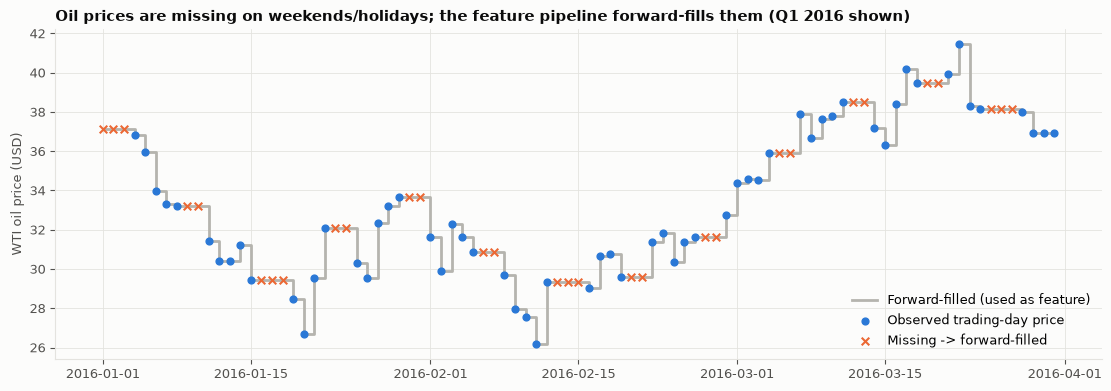

In [9]:
oil_calendar = pd.date_range(oil["date"].min(), oil["date"].max(), freq="D")
absent = oil_calendar.difference(oil["date"])
nan_rows = oil.loc[oil["dcoilwtico"].isna(), "date"]
print(
    f"oil.csv: {len(oil):,} rows over {len(oil_calendar):,} calendar days "
    f"({oil['date'].min().date()}..{oil['date'].max().date()})"
)
print(
    f"Calendar days with no row at all: {len(absent)} "
    f"({(absent.dayofweek >= 5).mean():.0%} of them weekends)"
)
print(
    f"Rows present but NaN price: {len(nan_rows)} (incl. the very first day, "
    f"{oil['date'].min().date()}: {bool(oil['dcoilwtico'].isna().iloc[0])})"
)
print(
    f"Total train-calendar days needing imputation: {oil_s.reindex(calendar).isna().sum()} "
    f"of {len(calendar)}"
)

zoom = slice("2016-01-01", "2016-03-31")
fig, ax = plt.subplots(figsize=(11, 3.8), layout="constrained")
ax.plot(
    oil_daily[zoom],
    color=CONTEXT,
    lw=2,
    drawstyle="steps-post",
    label="Forward-filled (used as feature)",
)
obs = oil_s[zoom].dropna()
ax.scatter(obs.index, obs, s=24, color=BLUE, zorder=3, label="Observed trading-day price")
gaps = oil_daily[zoom][oil_s.reindex(calendar)[zoom].isna()]
ax.scatter(
    gaps.index, gaps, s=30, marker="x", color=ORANGE, zorder=3, label="Missing -> forward-filled"
)
ax.set_ylabel("WTI oil price (USD)")
ax.set_title(
    "Oil prices are missing on weekends/holidays; the feature pipeline forward-fills them "
    "(Q1 2016 shown)"
)
ax.legend(loc="lower right")
save(fig, "08_oil_missing_data")